# Time to do some analysis based on the forest's predictions...
# This part might need a vhmem node from Sulis

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px
from plotly import graph_objects as go

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

In [2]:
# Note, we could read from the simplified csv, but reading the full thing with dask is actually faster
cluster = LocalCluster(threads_per_worker=1, n_workers=32, memory_limit='64GB')
client = Client(cluster)

pred_df = dd.read_parquet('pred_pubchem.parquet')
print(pred_df.columns)
print(len(pred_df))

simplified_df = pred_df[['idx', 'InChIID', 'InChIKey', 'SMILES', 'MolWt', 'LogP', 'BBB+', 'logBB']]
simplified_df = simplified_df.compute()
print(simplified_df.head())

#if not os.path.exists('pred_pubchem_simplified.csv'):
#    print('Not detecting existing CSV, writing a simplified one to file, this may take a while')
#    simplified_df.to_csv('pred_pubchem_simplified.csv')

Index(['idx', 'InChIID', 'InChIKey', 'MolWt', 'LogP', 'SMILES', 'C1CCSNC1',
       'C1CNOC1', 'BC', 'C1=CCCN2CCCC(CC1)C2',
       ...
       'C1=COCNC1', 'C1CCNCCCCNCCNCCNCCNCCNCC1', 'BO', 'C1=COCCO1',
       'C1=NCCCC1', 'C1=CCCC=CC=CCC2CCC(CCC=C1)OC2', 'C1COCN1', 'C1CCOC1',
       'BBB+', 'logBB'],
      dtype='object', length=401)
112194965
   idx                                            InChIID  \
0    1  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
1    2  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
2    3  InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...   
3    4         InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3   
4    5  InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...   

                      InChIKey                            SMILES       MolWt  \
0  RDHQFKQIGNGIED-UHFFFAOYSA-N  CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C  203.238007   
1  RDHQFKQIGNGIED-UHFFFAOYSA-O     CC(=O)OC(CC(=O)O)C[N+](C)(C)C  204.246002   
2  INCSWYKICIYAHB-UHFFFAOYSA-N              O=C

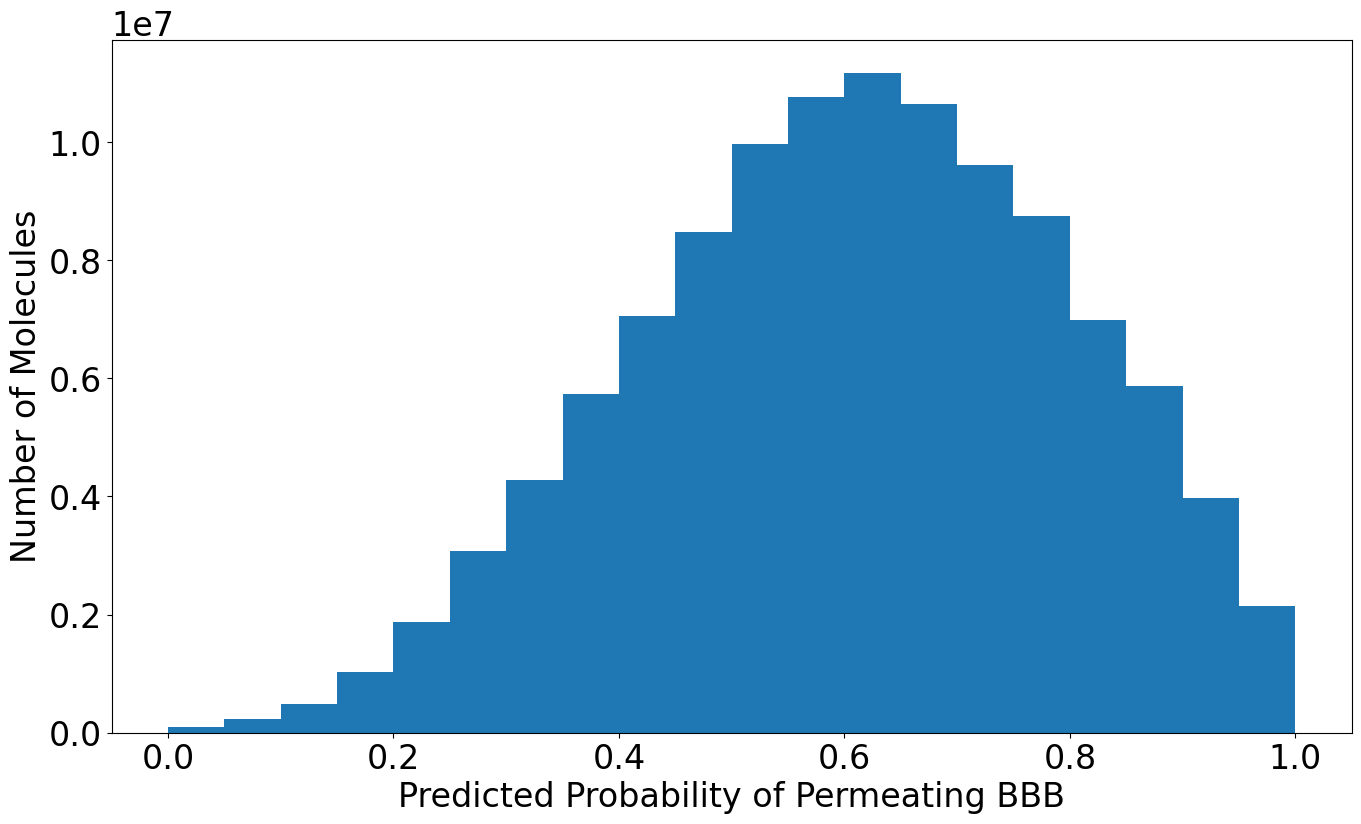

In [3]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['BBB+'], bins=20)
plt.xlabel('Predicted Probability of Permeating BBB', fontsize=24)
plt.ylabel('Number of Molecules', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)
plt.savefig('histogram_bbbp.png')

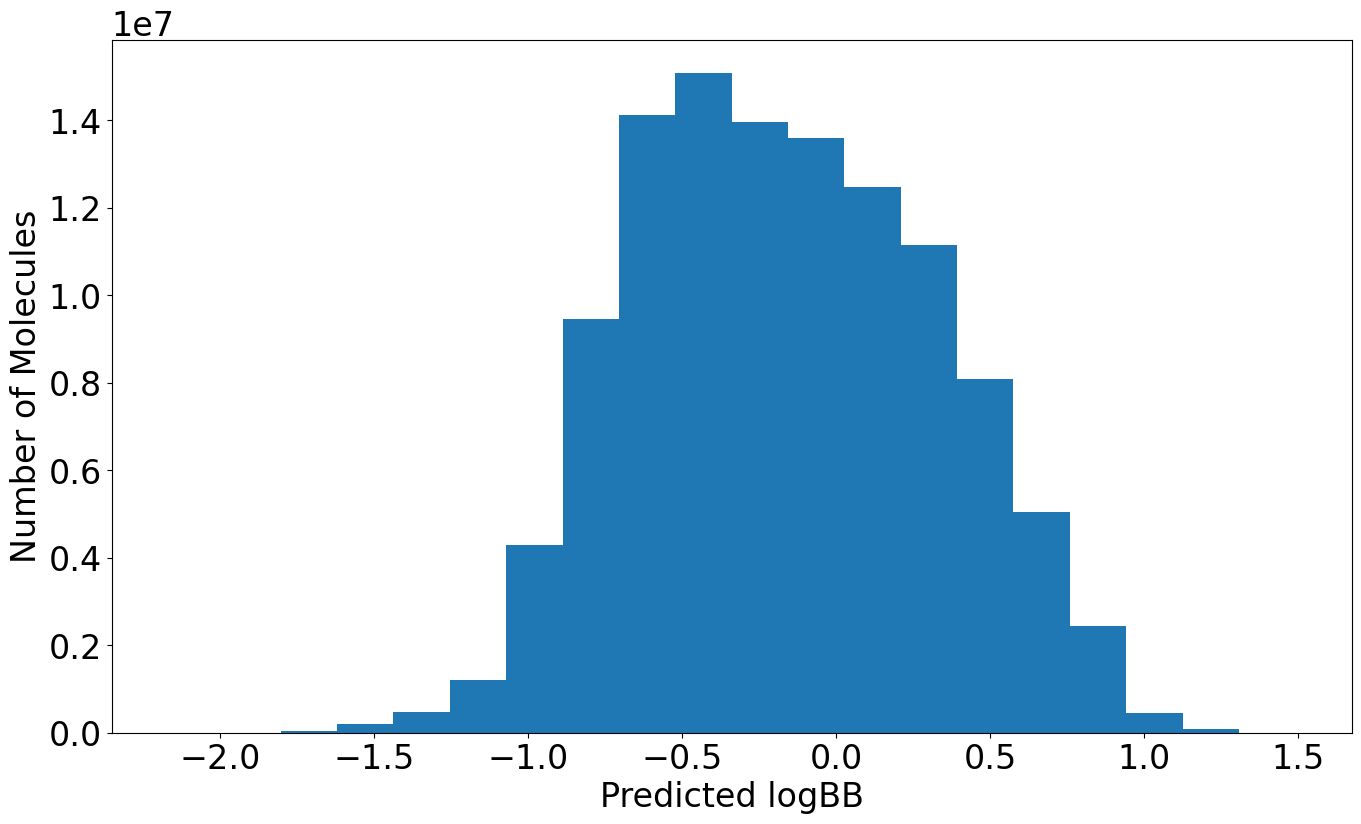

In [4]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['logBB'], bins=20)
plt.xlabel('Predicted logBB', fontsize=24)
plt.ylabel('Number of Molecules', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)
plt.savefig('histogram logbb.png')

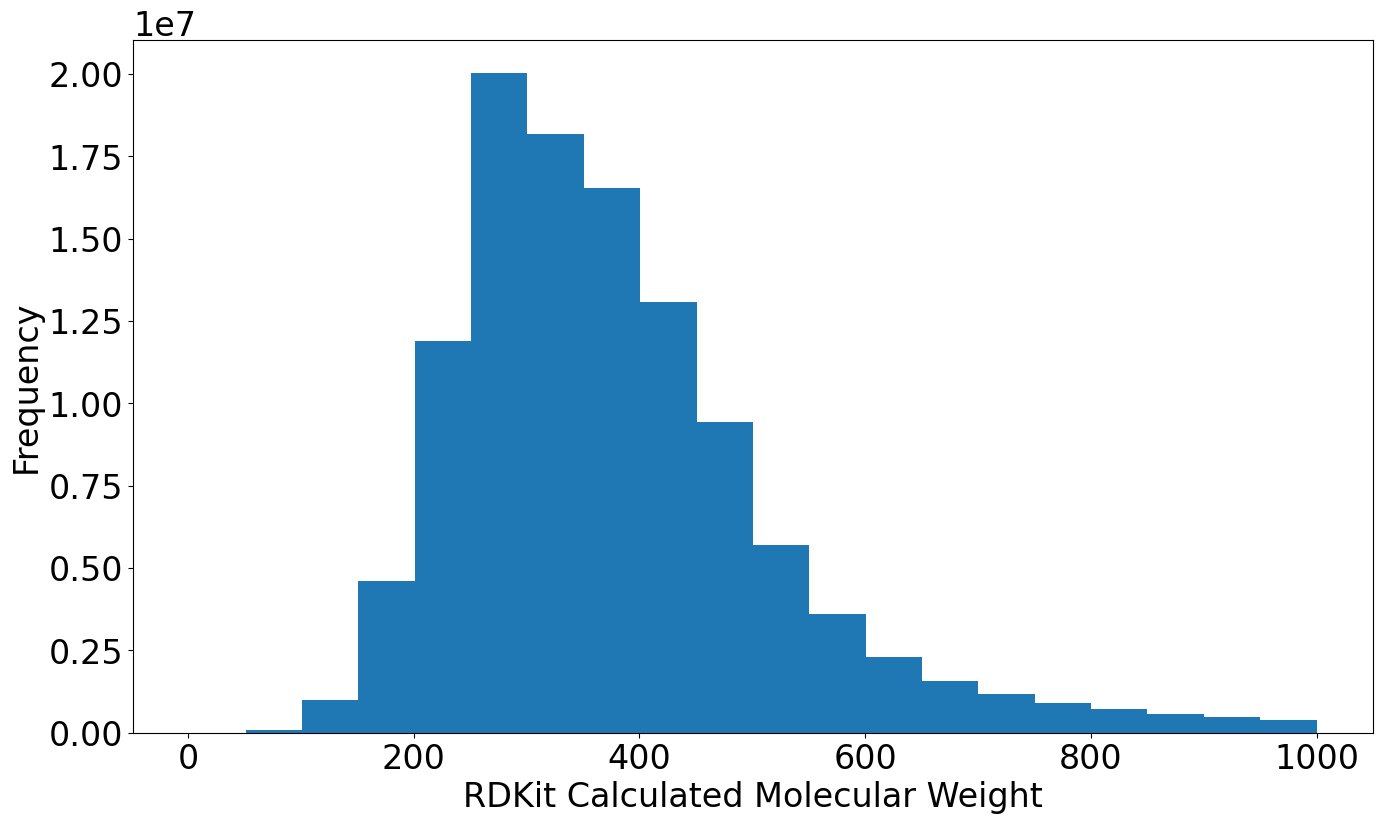

In [5]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['MolWt'], bins=20)
plt.xlabel('RDKit Calculated Molecular Weight', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

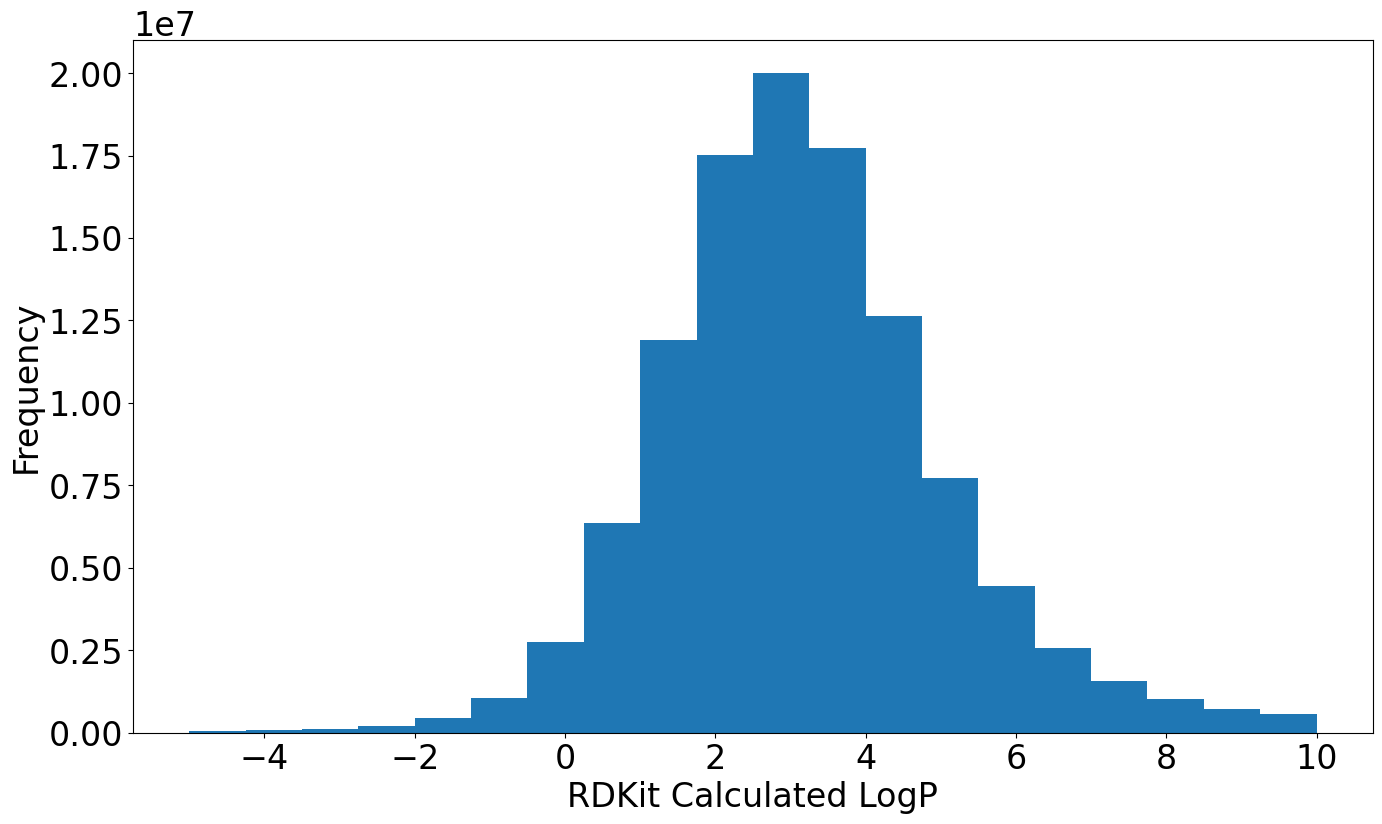

In [6]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['LogP'], bins=20, range=(-5,10))
plt.xlabel('RDKit Calculated LogP', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

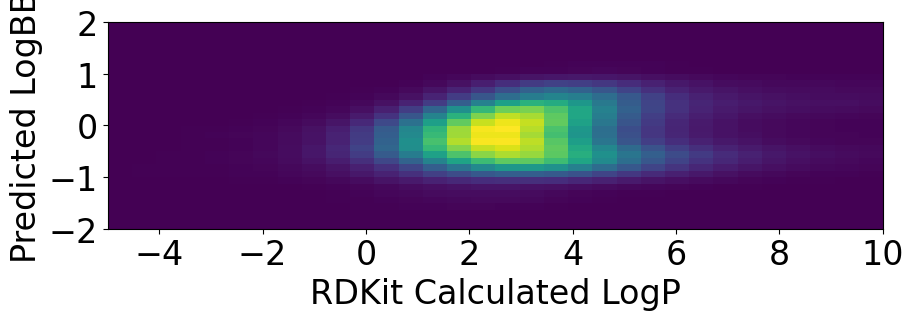

In [7]:
heatmap, xedges, yedges = np.histogram2d(simplified_df['LogP'], simplified_df['logBB'], bins=32, range=((-5,10),(-2,2)))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.figure(figsize=(10,10))
plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.xlabel('RDKit Calculated LogP', fontsize=24)
plt.ylabel('Predicted LogBB', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)